In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

In [4]:
from marine_qc import (
    combine_qc_results,
    do_iquam_track_check,
    do_multiple_sequential_check,
    do_spike_check,
)

In [5]:
from examples.data import get_sequential_data

C:\Users\llierham\mobaxterm\.venvs\mp_py\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# How to use quality control checks with sequential reports

We need some text!!!

In [6]:
data = get_sequential_data()
data

,ship_id,date,lat,lon,sst,vsi,dsi
0,ship_1,2026-07-01 00:00:00,44.919061,-29.771070,20.270235,18.000000,120.000000
1,ship_1,2026-07-01 01:00:00,44.814792,-29.530290,35.399830,18.931749,127.764571
2,ship_1,2026-07-01 02:00:00,44.688881,-29.278467,20.527780,19.800000,135.000000
3,ship_1,2026-07-01 03:00:00,44.544855,-29.017162,20.646629,20.545584,141.213203
4,ship_1,2026-07-01 04:00:00,44.387443,-28.748580,20.749549,21.117691,145.980762
5,ship_1,2026-07-01 05:00:00,44.221920,-28.475424,20.830890,21.477333,148.977775
6,ship_1,2026-07-01 06:00:00,44.053692,-28.200708,20.886577,21.600000,150.000000
7,ship_1,2026-07-01 07:00:00,43.888168,-27.927552,20.914328,21.477333,148.977775
8,ship_1,2026-07-01 08:00:00,43.730756,-27.658971,20.913721,21.117691,145.980762
9,ship_1,2026-07-01 09:00:00,43.586731,-27.397665,20.886160,20.545584,141.213203


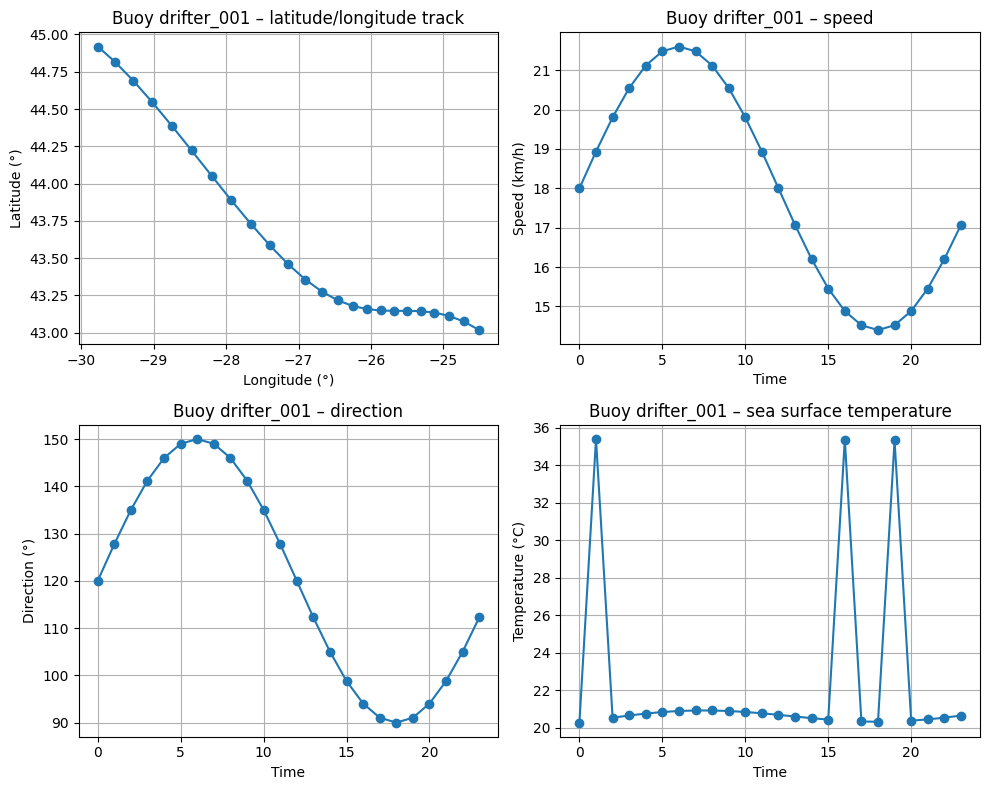

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0, 0].plot(data["lon"], data["lat"], marker="o", linestyle="-")
axs[0, 0].set_title("Buoy drifter_001 – latitude/longitude track")
axs[0, 0].set_xlabel("Longitude (°)")
axs[0, 0].set_ylabel("Latitude (°)")
axs[0, 0].grid(True)

axs[0, 1].plot(data["vsi"], marker="o", linestyle="-")
axs[0, 1].set_title("Buoy drifter_001 – speed")
axs[0, 1].set_xlabel("Time")
axs[0, 1].set_ylabel("Speed (km/h)")
axs[0, 1].grid(True)

axs[1, 0].plot(data["dsi"], marker="o", linestyle="-")
axs[1, 0].set_title("Buoy drifter_001 – direction")
axs[1, 0].set_xlabel("Time")
axs[1, 0].set_ylabel("Direction (°)")
axs[1, 0].grid(True)

axs[1, 1].plot(data["sst"], marker="o", linestyle="-")
axs[1, 1].set_title("Buoy drifter_001 – sea surface temperature")
axs[1, 1].set_xlabel("Time")
axs[1, 1].set_ylabel("Temperature (°C)")
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [8]:
qc_spike = do_spike_check(
    value=data.sst,
    lat=data.lat,
    lon=data.lon,
    date=data.date,
    max_gradient_space=0.5,
    max_gradient_time=1.0,
    delta_t=1.0,
    n_neighbours=5,
)
pd.DataFrame({"lat": data.lat, "lon": data.lon, "date": data.date, "sst": data.sst, "qc_spike": qc_spike})

,lat,lon,date,sst,qc_spike
0,44.919061,-29.771070,2026-07-01 00:00:00,20.270235,0
1,44.814792,-29.530290,2026-07-01 01:00:00,35.399830,1
2,44.688881,-29.278467,2026-07-01 02:00:00,20.527780,0
3,44.544855,-29.017162,2026-07-01 03:00:00,20.646629,0
4,44.387443,-28.748580,2026-07-01 04:00:00,20.749549,0
5,44.221920,-28.475424,2026-07-01 05:00:00,20.830890,0
6,44.053692,-28.200708,2026-07-01 06:00:00,20.886577,0
7,43.888168,-27.927552,2026-07-01 07:00:00,20.914328,0
8,43.730756,-27.658971,2026-07-01 08:00:00,20.913721,0
9,43.586731,-27.397665,2026-07-01 09:00:00,20.886160,0


In [9]:
qc_track = do_iquam_track_check(
    lat=data.lat,
    lon=data.lon,
    date=data.date,
    speed_limit=15.0,
    delta_d=1.11,
    delta_t=0.01,
    n_neighbours=5,
)
pd.DataFrame({"lat": data.lat, "lon": data.lon, "date": data.date, "qc_track": qc_track})

,lat,lon,date,qc_track
0,44.919061,-29.771070,2026-07-01 00:00:00,1
1,44.814792,-29.530290,2026-07-01 01:00:00,0
2,44.688881,-29.278467,2026-07-01 02:00:00,1
3,44.544855,-29.017162,2026-07-01 03:00:00,1
4,44.387443,-28.748580,2026-07-01 04:00:00,1
5,44.221920,-28.475424,2026-07-01 05:00:00,1
6,44.053692,-28.200708,2026-07-01 06:00:00,1
7,43.888168,-27.927552,2026-07-01 07:00:00,1
8,43.730756,-27.658971,2026-07-01 08:00:00,0
9,43.586731,-27.397665,2026-07-01 09:00:00,1


In [10]:
qc_dict = {
    "spike_check": {
        "func": "do_spike_check",
        "names": {
            "value": "sst",
            "lat": "lat",
            "lon": "lon",
            "date": "date",
        },
        "arguments": {
            "max_gradient_space": 0.5,
            "max_gradient_time": 1.0,
            "delta_t": 1.0,
            "n_neighbours": 5,
        },
    },
    "iquam_track_check": {
        "func": "do_iquam_track_check",
        "names": {
            "lat": "lat",
            "lon": "lon",
            "date": "date",
        },
        "arguments": {
            "speed_limit": 15.0,
            "delta_d": 1.11,
            "delta_t": 0.01,
            "n_neighbours": 5,
        },
    },
}

In [11]:
qc_multi = do_multiple_sequential_check(
    data,
    qc_dict=qc_dict,
    groupby="ship_id",
    return_method="failed",
)
qc_multi

,spike_check,iquam_track_check
0,0,1
1,1,3
2,0,1
3,0,1
4,0,1
5,0,1
6,0,1
7,0,1
8,0,0
9,0,1


In [12]:
qc_flag = combine_qc_results(qc_multi)

In [13]:
pd.DataFrame({**data, "qc_flag": qc_flag})

,ship_id,date,lat,lon,sst,vsi,dsi,qc_flag
0,ship_1,2026-07-01 00:00:00,44.919061,-29.771070,20.270235,18.000000,120.000000,1
1,ship_1,2026-07-01 01:00:00,44.814792,-29.530290,35.399830,18.931749,127.764571,1
2,ship_1,2026-07-01 02:00:00,44.688881,-29.278467,20.527780,19.800000,135.000000,1
3,ship_1,2026-07-01 03:00:00,44.544855,-29.017162,20.646629,20.545584,141.213203,1
4,ship_1,2026-07-01 04:00:00,44.387443,-28.748580,20.749549,21.117691,145.980762,1
5,ship_1,2026-07-01 05:00:00,44.221920,-28.475424,20.830890,21.477333,148.977775,1
6,ship_1,2026-07-01 06:00:00,44.053692,-28.200708,20.886577,21.600000,150.000000,1
7,ship_1,2026-07-01 07:00:00,43.888168,-27.927552,20.914328,21.477333,148.977775,1
8,ship_1,2026-07-01 08:00:00,43.730756,-27.658971,20.913721,21.117691,145.980762,0
9,ship_1,2026-07-01 09:00:00,43.586731,-27.397665,20.886160,20.545584,141.213203,1
